# 2. 사이킷런으로 시작하는 머신러닝

# 01 사이킷런 소개와 특징

## 사이킷런

- 사이킷런(scikit-learn): 파이썬 머신러닝 라이브러리 중 가장 많이 사용되는 라이브러리

## 사이킷런의 특징

1.  쉽고 가장 파이썬스러운 API 제공
2.  머신러닝을 위한 다양한 알고리즘과 개발에 편리한 프레임워크
3. 오랜 기간 실전 환경에서 검증된 성숙한 라이브러리



In [3]:
import sklearn
print(sklearn.__version__)

1.6.1


---

# 02 첫 번째 머신러닝 만들어 보기 - 붓꽃 품종 예측하기

## 붓꽃 데이터 세트
- 꽃잎의 길이와 너비
- 꽃받침의 길이와 너비 피처를 기반으로 꽃의 품종 예측

## 분류(Classfication)
- 대표적인 지도학습 방법
- 학습을 위한 다양한 피처와 분류 결정값인 레이블(Label) 데이터로 모델을 학습한 뒤,
- 별도의 테스트 데이터 세트에서 미지의 레이블 예측

### 학습 데이터 세트
- 학습을 위해 주어진 데이터 세트

### 테스트 데이터 세트
- 머신러닝 모델의 예측 성능을 평가하기 위해 별도로 주어진 데이터 세트

```
sklearn.tree
```
- 트리 기반 ML 알고리즘을 구현한 클래스의 모임
```
sklearn.model_selection
```
- 학습 데이터와 검증 데이터, 예측 데이터로 데이터를 분리하거나 최적의 하이퍼 파라미터로 평가하기 위한 다양한 모듈의 모임

### 하이퍼파라미터
- 머신러닝 알고리즘별로 최적의 학습을 위해 직접 입력하는 파라미터를 통칭
- 머신러닝 알고리즘의 성능을 튜닝할 수 있음
```
load_iris()
```
- 붓꽃 데이터 세트를 생성하는 데 이용

```
train_test_split()
```
- 데이터 세트를 학습 데이터와 테스트 데이터로 분리하는 데 사용할 함수

In [5]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

♣ `load_iris()` 함수를 이용해 붓꽃 데이터를 로딩한 후, 피처들과 데이터 값이 어떻기 구성돼 있는지 확인하기 위해 DataFrame으로 변환
-

In [12]:
import pandas as pd

# 붓꽃 데이터 세트 로딩
iris = load_iris()

# iris.data는 Iris 데이터 세트에서 피처(feature)만으로 된 데이터를 numpy로 가지고 있음
iris_data = iris.data

# iris.target은 붓꽃 데이터 세트에서 레이블(결정 값) 데이터를 numpy로 가지고 있음
iris_label = iris.target
print('irst target값:', iris_label)
print('irst target명:', iris.target_names)

# 붓꽃 데이터 세트를 자세히 보기 위해 DataFrame으로 변환
iris_df = pd.DataFrame(data=iris_data, columns=iris.feature_names)
iris_df['label'] = iris.target

iris_df.head(3)

irst target값: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
irst target명: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0


In [ ]:
# 피처: sepal length, sepal width, petal length, petal width
# 레이블: 0, 1, 2
# 0: Setosa 품종
# 1: versicolor 품종
# 2: virginica 품종

`train_test_split()`을 이용해 학습용 데이터와 테스트용 데이터로 분리
-
- test_size=0.2
- 전체 데이터 중 테스트 데이터 20%, 학습 데이터가 80%로 분할

In [8]:
X_train, X_test, y_train, y_test = train_test_split(iris_data, iris_label, test_size=0.2, random_state=11)

♣ 해당 데이터를 기반으로 머신러닝 분류 알고리즘의 하나인 의사결정 트리를 이용해 학습과 예측 수행
-

In [9]:
# DecisionTreeClassfier 객체 생성
df_clf = DecisionTreeClassifier(random_state=11)

# 학습 수행
df_clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=11)

In [10]:
# 학습이 완료된 DecisionTreeClassifier 객체에서 테스트 데이터 세트로 예측 수행
pred = df_clf.predict(X_test)

In [11]:
# 예측 성능 평가
from sklearn.metrics import accuracy_score
print('예측 정확도: {0:.4f}'.format(accuracy_score(y_test, pred)))

예측 정확도: 0.9333


♣ 붓꽃 데이터 세트로 분류를 예측한 프로세스 정리
-
- 데이터 세트 분리: 데이터를 학습 데이터와 테스트 데이터로 분리
- 모델 학습: 학습 데이터를 기반으로 ML 알고리즘을 적용해 모델 학습
- 예측 수행: 학습된 ML 모델을 이용해 테스트 데이터의 분류(즉, 붓꽃 종류)를 예측
- 평가: 예측된 결과값과 테스트 데이터의 실제 결과값을 비교해 ML 모델의 성능 평가

---

# 03 사이킷런 기반 프레임워크 익히기

## Estimator 이해 및 fit(), predict() 메서드
- `fit()`: ML 모델 학습 메서드
- `predict()`: 학습된 모델의 예측을 위한 메서드

♣ 지도학습의 주요 두 축인 분류와 회귀의 다양한 알고리즘을 구현한 모든 사이킷런 클래스는 `fit()`과 `predict()`만을 이용해 간단하게 학습과 예측 결과를 반환함
-

### Classifier
- 분류 알고리즘을 구현한 클래스
### Regressor
- 회귀 알고리즘을 구현한 클래스
### Estimator
- Classifier와 Regressor를 합쳐서 지칭
- 지도학습의 모든 알고리즘을 구현한 클래스를 통칭
- `fit()`과 `predict()`를 내부에서 구현


♣ 비지도학습인 차원 축소, 클러스터링, 피처 추출 등을 구현한 클레스 역시 대부분 `fit()`과 `transform()`을 적용함
-
- `fit()`: 입력 데이터의 형태에 맞춰 데이터를 변환하기 위한 사전 구조를 맞추는 작업
- 지도학습의 fit()과는 역할이 다름
- `transform()`: 입력 데이터의 차원 변환, 클러스터링, 피처 추출 등의 실제 작업 수행

## 사이킷런의 주요 모듈

```
sklearn.dataset
```
- 사이킷런에 내장되어 예제로 제공하는 데이터 세트

```
sklearn.preprocessing
```
- 데이터 전처리에 필요한 다양한 가공 기능 제공
- 문자열을 숫자형 코드 값으로 인코딩, 정규화, 스케일링 등
```
sklearn.feature_selection
```
- 알고리즘에 큰 영향을 미치는 피처를 우선순위대로 셀렉션 작업을 수행
```
sklearn.feature_extracton
```
- 텍스트나 이미지 데이터의 벡터화된 피처를 추출하는 데 사용
```
sklearn.decomposition
```
- 차원 축소와 관련한 알고리즘을 지원하는 모듈
- PCA, NMF, Truncated SVD 등을 통해 차원 축소 기능 수행
```
sklearn.model_selection
```
- 교차 검증을 위한 학습용/테스트용 분리
- 그리드 서치(Grid Search)로 최적 파라미터 추출
```
sklearn.metrics
```
- 분류, 회귀, 클러스터링, 페어와이즈(Pairwise)에 대한 다양한 성능 측정 방법 제공
- Accuracy, Precision, Recall, ROC-AUC, RMSE 등 제공

ML 알고리즘
-
- `sklearn.ensemble`
- `sklearn.linear_model`
- `sklearn.naive_bayes`
- `sklearn.neighbors`
- `sklearn.svm`
- `sklearn.tree`
- `sklearn.cluster`

유틸리티
-
- `sklearn.pipeline`

♧ 일반적으로 머신러닝 모델을 구축하는 주요 프로세스
-
- 피처 처리: 피처의 가공, 변경, 추출을 수행
- ML 알고리즘 학습/예측 수행
- 모델 평가

## 내장된 예제 데이터 세트

- `datasets.load_boston()`: 회귀 용도, 미국 보스턴의 집 피처들과 가격에 대한 데이터 세트
- `datasets.load_breast_cancer()`: 분류 용도, 위스콘신 유방암 피처들과 악성/음성 레이블 데이터 세트
- `datasets.load.diabetes()`: 회귀 용도, 당뇨 데이터 세트
- `datasets.load_digits()`: 분류 용도, 0에서 9까지 숫자의 이미지 픽셀 데이터 세트
- `datasets.load_iris()`: 분류 용도, 붓꽃에 대한 피처를 가진 데이터 세트

fetch 계열 명령은 데이터 크기가 커서 패키지에 처음부터 저장돼 있지 않고 인터넷에 내려받아 홈 디렉터리 아래의 scikit_learn_data라는 서브 디렉터리에 저장한 후 추후 불러들이는 데이터
-
- `fetch_covtype()`: 회귀 분석용 토지 조사 자료
- `fetch_20newsgroups()`: 뉴스 그룹 텍스트 자료
- `fetch_olivetti_faces()`: 얼굴 이미지 자료
- `fetch_lfw_people()`: 얼굴 이미지 자료
- `fetch_lfw_pairs()`: 얼굴 이미지 자료
- `fetch_rcv1()`: 로이터 뉴스 말뭉치
- `fetch_mldata()`: ML 웹사이트에서 다운로드

표본 데이터 생성기 대표 2가지
-
```
datasets.make_classifications()
```
- 분류를 위한 데이터 세트 생성
```
datasets.make_blobs()
```
- 클러스터링을 위한 데이터 세트 무작위 생성

사이킷런에 내장된 데이터 세트는 일반적으로 딕셔너리 형태
-
키는 보통 data, target, name, feature_names, DESCR로 구성
-
- data, target은 넘파이 배열(ndarray) 타입
- target_names, feature_names는 넘파이 배열 또는 파이썬 리스트(list) 타입
- DESCR은 스트링 타입


In [14]:
# Bunch 클래스는 파이썬 딕셔너리 자료형과 유사
from sklearn.datasets import load_iris

iris_data = load_iris()
print(type(iris_data))

<class 'sklearn.utils._bunch.Bunch'>


In [16]:
keys = iris_data.keys()
print('붓꽃 데이터 세트의 키들:', keys)

붓꽃 데이터 세트의 키들: dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [20]:
print('\n feature_names의 type:', type(iris_data.feature_names))
print('feature names의 shape:', len(iris_data.feature_names))
print(iris_data.feature_names)

print('\n target_names의 type:', type(iris_data.target_names))
print('target_names의 shape:', len(iris_data.target_names))
print(iris_data.target_names)

print('\n data의 type:', type(iris_data.data))
print('data의 shape:', iris_data.data.shape)
print(iris_data['data'])

print('\n target의 type:', type(iris_data.target))
print('target의 shape:', iris_data.target.shape)
print(iris_data.target)


 feature_names의 type: <class 'list'>
feature names의 shape: 4
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

 target_names의 type: <class 'numpy.ndarray'>
target_names의 shape: 3
['setosa' 'versicolor' 'virginica']

 data의 type: <class 'numpy.ndarray'>
data의 shape: (150, 4)
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 

---

# 04 Model Selection 모듈 소개

## 학습/테스트 데이터 세트 분리 - train_test_split()

In [30]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

iris = load_iris()
dt_clf = DecisionTreeClassifier()
train_data = iris.data
train_label = iris.target
dt_clf.fit(train_data, train_label)

# 학습 데이터 세트로 예측 수행
# 이미 학습한 학습 데이터 세트로 예측해서 정확도가 100%가 나와버림
pred = dt_clf.predict(train_data)
print('예측 정확도:', accuracy_score(train_label, pred))

예측 정확도: 1.0


In [31]:
# 예측을 수행하는 데이터 세트는 테스트 데이터 세트여야 함
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

dt_clf = DecisionTreeClassifier()
iris_data = load_iris()

X_train, X_test, y_train, y_test = train_test_split(iris_data.data, iris_data.target, test_size=0.3, random_state=121)

In [33]:
dt_clf.fit(X_train, y_train)
pred = dt_clf.predict(X_test)
print('예측 정확도: {0:.4f}'.format(accuracy_score(y_test, pred)))

예측 정확도: 0.9556


## 교차 검증

별도의 테스트용 데이터를 이용해 예측 성능을 평가하는 방법 역시 과적합(Overfitting)에 취약한 약점이 있음
-
- 과적합: 모델이 학습 데이터에만 과도하게 최적화되어, 실제 에측을 다른 데이터로 수행할 경우에는 예측 성능이 과도하게 떨어지는 것

데이터 편증을 막기 위해 별도의 여러 세트로 구성된 학습 데이터 세트와 검증 데이터 세트에서 학습과 평가를 수행하는 것
-


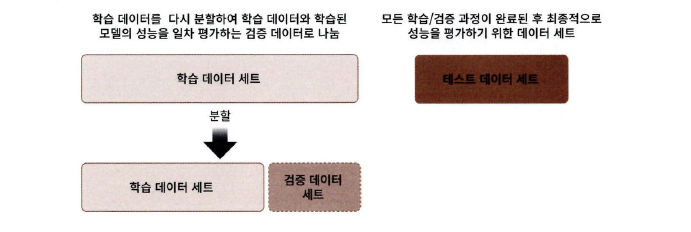

K 폴드 교차 검증
-
- 가장 보편적으로 사용되는 기법
- K개의 데이터 폴드 세트를 만들어 K번만큼 각 폴트 세트에 학습과 검증 평가를 반복적으로 수행함

In [38]:
from sklearn.model_selection import KFold
import numpy as np

iris = load_iris()
features = iris.data
label = iris.target
dt_clf = DecisionTreeClassifier(random_state=156)

# 5개의 폴드 세트로 분리하는 KFold 객체와 폴드 세트별 정확도를 담을 리스트 객체 생성
kfold = KFold(n_splits=5)
cv_accuracy = []
print('붓꽃 데이터 세트 크기:', features.shape[0])

붓꽃 데이터 세트 크기: 150


In [42]:
# 학습용 데이터 세트는 4/5인 120개
# 검증용 데이터 세트는 1/5d인 30개

n_iter = 0

# KFold 객체의 split()를 호출하면 폴드별 학습용, 검증용 테스트의 로우 인덱스를 array로 변환
for train_index, test_index in kfold.split(features):
    # kfold.split()으로 반환된 인덱스를 이용해 학습용, 검증용 테스트 데이터 추출
    X_train, X_test = features[train_index], features[test_index]
    y_train, y_test = label[train_index], label[test_index]
    # 학습 및 예측
    dt_clf.fit(X_train, y_train)
    pred = dt_clf.predict(X_test)
    n_iter += 1
    # 반복 시마다 정확도 측정
    accuracy = np.round(accuracy_score(y_test, pred), 4)
    train_size = X_train.shape[0]
    test_size = X_test.shape[0]
    print('\n#{0} 교차 검증 정확도: {1}, 학습 데이터 크기: {2}, 검증 데이터 크기: {3}'.format(n_iter, accuracy, train_size, test_size))
    print('#{0} 검증 세트 인덱스: {1}'.format(n_iter, test_index))
    cv_accuracy.append(accuracy)

# 개별 iteration별 정확도를 합하여 평균 정확도 계산
print('\n 평균 검증 정확도:', np.mean(cv_accuracy))


#1 교차 검증 정확도: 1.0, 학습 데이터 크기: 120, 검증 데이터 크기: 30
#1 검증 세트 인덱스: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]

#2 교차 검증 정확도: 0.9667, 학습 데이터 크기: 120, 검증 데이터 크기: 30
#2 검증 세트 인덱스: [30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53
 54 55 56 57 58 59]

#3 교차 검증 정확도: 0.8667, 학습 데이터 크기: 120, 검증 데이터 크기: 30
#3 검증 세트 인덱스: [60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83
 84 85 86 87 88 89]

#4 교차 검증 정확도: 0.9333, 학습 데이터 크기: 120, 검증 데이터 크기: 30
#4 검증 세트 인덱스: [ 90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119]

#5 교차 검증 정확도: 0.7333, 학습 데이터 크기: 120, 검증 데이터 크기: 30
#5 검증 세트 인덱스: [120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137
 138 139 140 141 142 143 144 145 146 147 148 149]

 평균 검증 정확도: 0.9


Stratified K 폴드
-
- 불균형한 분포도를 가진 레이블 데이터 집합을 위한 K 폴드 방식
- 특정 레이블 값이 특이하게 많거나 매우 적어서 값의 분포가 한쪽으로 치우치는 것

In [43]:
import pandas as pd

iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['label'] = iris.target
iris_df['label'].value_counts()

,count
label,
0,50
1,50
2,50


In [45]:
kfold = KFold(n_splits=3)
n_iter = 0
for train_index, test_index in kfold.split(iris_df):
    n_iter += 1
    label_train = iris_df['label'].iloc[train_index]
    label_test = iris_df['label'].iloc[test_index]
    print('## 교차 검증: {0}'.format(n_iter))
    print(' 학습 레이블 데이터 분포:\n', label_train.value_counts())
    print(' 검증 레이블 데이터 분포:\n', label_test.value_counts())

## 교차 검증: 1
 학습 레이블 데이터 분포:
 label
1    50
2    50
Name: count, dtype: int64
 검증 레이블 데이터 분포:
 label
0    50
Name: count, dtype: int64
## 교차 검증: 2
 학습 레이블 데이터 분포:
 label
0    50
2    50
Name: count, dtype: int64
 검증 레이블 데이터 분포:
 label
1    50
Name: count, dtype: int64
## 교차 검증: 3
 학습 레이블 데이터 분포:
 label
0    50
1    50
Name: count, dtype: int64
 검증 레이블 데이터 분포:
 label
2    50
Name: count, dtype: int64


In [46]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=3)
n_iter = 0

for train_index, test_index in skf.split(iris_df, iris_df['label']):
    n_iter += 1
    label_train = iris_df['label'].iloc[train_index]
    label_test = iris_df['label'].iloc[test_index]
    print('## 교차 검증: {0}'.format(n_iter))
    print(' 학습 레이블 데이터 분포:\n', label_train.value_counts())
    print(' 검증 레이블 데이터 분포:\n', label_test.value_counts())

## 교차 검증: 1
 학습 레이블 데이터 분포:
 label
2    34
0    33
1    33
Name: count, dtype: int64
 검증 레이블 데이터 분포:
 label
0    17
1    17
2    16
Name: count, dtype: int64
## 교차 검증: 2
 학습 레이블 데이터 분포:
 label
1    34
0    33
2    33
Name: count, dtype: int64
 검증 레이블 데이터 분포:
 label
0    17
2    17
1    16
Name: count, dtype: int64
## 교차 검증: 3
 학습 레이블 데이터 분포:
 label
0    34
1    33
2    33
Name: count, dtype: int64
 검증 레이블 데이터 분포:
 label
1    17
2    17
0    16
Name: count, dtype: int64


In [47]:
dt_clf = DecisionTreeClassifier(random_state=156)

skfold = StratifiedKFold(n_splits=3)
n_iter = 0
cv_accuracy = []

# StratifiedKFold의 split() 호출 시 반드시 레이블 데이터 세트도 추가 입력 필요
for train_index, test_index in skfold.split(features, label):
    # split()으로 반환된 인덱스를 이용해 학습용, 검증용 테스트 데이터 추출
    X_train, X_test = features[train_index], features[test_index]
    y_train, y_test = label[train_index], label[test_index]
    # 학습 및 예측
    dt_clf.fit(X_train, y_train)
    pred = dt_clf.predict(X_test)

    # 반복 시마다 정확도 측정
    n_iter += 1
    accuracy = np.round(accuracy_score(y_test, pred), 4)
    train_size = X_train.shape[0]
    test_size = X_test.shape[0]
    print('\n#{0} 교차 검증 정확도: {1}, 학습 데이터 크기: {2}, 검증 데이터 크기: {3}'.format(n_iter, accuracy, train_size, test_size))
    print('#{0} 검증 세트 인덱스: {1}'.format(n_iter, test_index))
    cv_accuracy.append(accuracy)

# 교차 검증별 정확도 및 평균 정확도 계산
print('\n## 교차 검증별 정확도:', np.round(cv_accuracy, 4))
print('## 평균 검증 정확도:', np.round(np.mean(cv_accuracy),4))


#1 교차 검증 정확도: 0.98, 학습 데이터 크기: 100, 검증 데이터 크기: 50
#1 검증 세트 인덱스: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  50
  51  52  53  54  55  56  57  58  59  60  61  62  63  64  65  66 100 101
 102 103 104 105 106 107 108 109 110 111 112 113 114 115]

#2 교차 검증 정확도: 0.94, 학습 데이터 크기: 100, 검증 데이터 크기: 50
#2 검증 세트 인덱스: [ 17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  67
  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82 116 117 118
 119 120 121 122 123 124 125 126 127 128 129 130 131 132]

#3 교차 검증 정확도: 0.98, 학습 데이터 크기: 100, 검증 데이터 크기: 50
#3 검증 세트 인덱스: [ 34  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49  83  84
  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99 133 134 135
 136 137 138 139 140 141 142 143 144 145 146 147 148 149]

## 교차 검증별 정확도: [0.98 0.94 0.98]
## 평균 검증 정확도: 0.9667


교차 검증을 보다 간편하게 - cross_val_score()
-

In [50]:
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.datasets import load_iris

iris_data = load_iris()
dt_clf = DecisionTreeClassifier(random_state=156)

data = iris_data.data
label = iris_data.target

# 성능 지표는 정확도(accuracy), 교차 검증 세트는 3개
scores = cross_val_score(dt_clf, data, label, scoring='accuracy', cv=3)
print('교차 검증별 정확도:', np.round(scores, 4))
print('평균 검증 정확도:', np.round(np.mean(scores),4))

교차 검증별 정확도: [0.98 0.94 0.98]
평균 검증 정확도: 0.9667


---

## GridSearchCV - 교차 검증과 최적 하이퍼 파라미터 튜닝을 한 번에

In [51]:
grid_parameters = {'max_depth': [1, 2, 3],
                   'min_samples_split': [2, 3]
                   }

In [52]:
from sklearn.model_selection import GridSearchCV

# 데이터 로딩하고 학습 데이터와 테스트 데이터 분리
iris_data = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris_data.data, iris_data.target, test_size=0.2, random_state=121)

dtree = DecisionTreeClassifier()

## 파라미터를 딕셔너리 형태로 설정
parameters = {'max_depth': [1, 2, 3], 'min_samples_split': [2, 3]}

In [53]:
# param_grid의 하이퍼 파라미터를 3개의 train, test set fold로 나누어 테스트 수행 설정
### refit=True가 default임. True이면 가장 좋은 파라미터 설정으로 재학습시킴
grid_dtree = GridSearchCV(dtree, param_grid=parameters, cv=3, refit=True)

# 붓꽃 학습 데이터로 param_grid의 하이퍼 파라미터를 순차적으로 학습/평가
grid_dtree.fit(X_train, y_train)

# GridSearchCV 결과를 추출해 DataFrame으로 변환
scores_df = pd.DataFrame(grid_dtree.cv_results_)
scores_df[['params', 'mean_test_score', 'rank_test_score', 'split0_test_score', 'split1_test_score', 'split2_test_score']]

,params,mean_test_score,rank_test_score,split0_test_score,split1_test_score,split2_test_score
0,"{'max_depth': 1, 'min_samples_split': 2}",0.700000,5,0.700,0.7,0.70
1,"{'max_depth': 1, 'min_samples_split': 3}",0.700000,5,0.700,0.7,0.70
2,"{'max_depth': 2, 'min_samples_split': 2}",0.958333,3,0.925,1.0,0.95
3,"{'max_depth': 2, 'min_samples_split': 3}",0.958333,3,0.925,1.0,0.95
4,"{'max_depth': 3, 'min_samples_split': 2}",0.975000,1,0.975,1.0,0.95
5,"{'max_depth': 3, 'min_samples_split': 3}",0.975000,1,0.975,1.0,0.95


params 칼럼에는 수행할 때마다 적용된 개별 하이퍼 파라미터 값을 나타냄
-
rank_test_score는 하이퍼 파라미터별로 성능이 좋은 score 순위를 나타냄
-
mean_test_score는 개별 하이퍼 파라미터별로 CV의 폴딩 테스트 세트에 대해 총 수행한 평가 평균값
-

In [55]:
print('GridSearchCV 최적 파라미터:', grid_dtree.best_params_)
print('GridSearchCV 최고 정확도:{0:.4f}'.format(grid_dtree.best_score_))

GridSearchCV 최적 파라미터: {'max_depth': 3, 'min_samples_split': 2}
GridSearchCV 최고 정확도:0.9750


In [56]:
# GridSearchCV의 refit으로 이미 학습된 estimator 반환
estimator = grid_dtree.best_estimator_

# GridSearchCV의 best_estimator_는 이미 최적 학습됐으므로 별도 학습이 필요 없음
pred = estimator.predict(X_test)
print('테스트 데이터 세트 정확도:{0:.4f}'.format(accuracy_score(y_test, pred)))

테스트 데이터 세트 정확도:0.9667


---

# 05 데이터 전처리

## 데이터 인코딩

### 레이블 인코딩
- 카테고리 피처를 코드형 숫자 값으로 변환하는 것

In [58]:
from sklearn.preprocessing import LabelEncoder

items=['TV', '냉장고','전자레인지', '컴퓨터', '선풍기', '믹서', '믹서']

# LabelEncoder를 객체로 생성한 후, fit()과 transform()으로 레이블 인코딩 수행
encoder = LabelEncoder()
encoder.fit(items)
labels = encoder.transform(items)
print('인코딩 변환값:', labels)

인코딩 변환값: [0 1 4 5 3 2 2]


In [59]:
print('인코딩 클래스:', encoder.classes_)

인코딩 클래스: ['TV' '냉장고' '믹서' '선풍기' '전자레인지' '컴퓨터']


In [60]:
print('디코딩 원본값:', encoder.inverse_transform([4, 5, 2, 0, 1, 1, 3, 3]))

디코딩 원본값: ['전자레인지' '컴퓨터' '믹서' 'TV' '냉장고' '냉장고' '선풍기' '선풍기']


♤ 냉장고가 1, 믹서가 2로 변환되면, 1보다 2가 더 큰 값이므로 특정 ML 알고리즘에서 가중치가 부여되거나 더 중요하게 인식할 가능성이 발생함
-
- 레이블 인코딩은 선형 회귀와 같은 ML 알고리즘에는 적용하지 않아야 함
- 트리 계열 ML 알고리즘은 숫자의 이러한 특성을 반영하지 않으므로 별문제 없음


### 원-핫 인코딩(One-Hot Encoding)

In [63]:
from sklearn.preprocessing import OneHotEncoder

items=['TV', '냉장고','전자레인지', '컴퓨터', '선풍기', '선풍기', '믹서', '믹서']

# 2차원 ndarray로 변환
items = np.array(items).reshape(-1, 1)

# 원-핫 인코딩 적용
oh_encoder = OneHotEncoder()
oh_encoder.fit(items)
oh_labels = oh_encoder.transform(items)

# OneHotEncoder로 변환한 결과는 희소행렬이므로 toarray()를 이용해 밀집 행렬로 변환
print('원-핫 인코딩 데이터')
print(oh_labels.toarray())
print('원-핫 인코딩 데이터 차원')
print(oh_labels.shape)

원-핫 인코딩 데이터
[[1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]]
원-핫 인코딩 데이터 차원
(8, 6)


In [64]:
import pandas as pd

df = pd.DataFrame({'item':['TV', '냉장고','전자레인지', '컴퓨터', '선풍기', '선풍기', '믹서', '믹서']})
pd.get_dummies(df)

,item_TV,item_냉장고,item_믹서,item_선풍기,item_전자레인지,item_컴퓨터
0,True,False,False,False,False,False
1,False,True,False,False,False,False
2,False,False,False,False,True,False
3,False,False,False,False,False,True
4,False,False,False,True,False,False
5,False,False,False,True,False,False
6,False,False,True,False,False,False
7,False,False,True,False,False,False


## 피처 스케일링과 정규화

### 피처 스케일링: 서로 다른 변수의 값 범위를 일정한 수준으로 맞추는 작업
- 표준화: 데이터의 피처 각각이 평균이 0이고 분산이 1인 가우시안 정규 분포를 가진 값으로 변환
- 정규화: 서로 다른 피처의 크기를 통일하기 위해 크기를 변환해주는 개념

## StandardScaler

In [65]:
# 붓꽃 데이터 세트 로딩하고 DataFrame으로 변환
iris = load_iris()
iris_data = iris.data
iris_df = pd.DataFrame(data=iris_data, columns=iris.feature_names)

print('feature 들의 평균 값')
print(iris_df.mean())
print('\nfeature 들의 분산 값')
print(iris_df.var())

feature 들의 평균 값
sepal length (cm)    5.843333
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199333
dtype: float64

feature 들의 분산 값
sepal length (cm)    0.685694
sepal width (cm)     0.189979
petal length (cm)    3.116278
petal width (cm)     0.581006
dtype: float64


In [66]:
from sklearn.preprocessing import StandardScaler

# StandardScaler 객체 생성
scaler = StandardScaler()
# StandardScaler로 데이터 세트 변환, fit()과 transform() 호출
scaler.fit(iris_df)
iris_scaled = scaler.transform(iris_df)

# transform()시 스케일 변환된 데이터 세트가 Numpy ndarray로 변환돼 이를 DataFrame으로 변환
iris_df_scaled = pd.DataFrame(data=iris_scaled, columns=iris.feature_names)
print('feature 들의 평균 값')
print(iris_df_scaled.mean())
print('\nfeature 들의 분산 값')
print(iris_df_scaled.var())

feature 들의 평균 값
sepal length (cm)   -1.690315e-15
sepal width (cm)    -1.842970e-15
petal length (cm)   -1.698641e-15
petal width (cm)    -1.409243e-15
dtype: float64

feature 들의 분산 값
sepal length (cm)    1.006711
sepal width (cm)     1.006711
petal length (cm)    1.006711
petal width (cm)     1.006711
dtype: float64


## MinMaxScaler

In [68]:
from sklearn.preprocessing import MinMaxScaler

# MinMaxScaler 객체 생성
scaler = MinMaxScaler()
# MinMaxScaler로 데이터 세트 변환, fit()과 transform() 호출
scaler.fit(iris_df)
iris_scaled = scaler.transform(iris_df)

# transform()시 스케일 변환된 데이터 세트가 Numpy ndarray로 변환돼 이를 DataFrame으로 변환
iris_df_scaled = pd.DataFrame(data=iris_scaled, columns=iris.feature_names)
print('feature 들의 최솟값')
print(iris_df_scaled.min())
print('\nfeature 들의 최댓값')
print(iris_df_scaled.max())

feature 들의 최솟값
sepal length (cm)    0.0
sepal width (cm)     0.0
petal length (cm)    0.0
petal width (cm)     0.0
dtype: float64

feature 들의 최댓값
sepal length (cm)    1.0
sepal width (cm)     1.0
petal length (cm)    1.0
petal width (cm)     1.0
dtype: float64


## 학습 데이터와 테스트 데이터의 스케일링 변환 시 유의점

- 학습 데이터로 `fit()`이 적용된 스케일링 기준 정보를 그대로 테스트 데이터에 적용해야 하며,
- 테스트 데이터로 다시 새로운 스케일링 기준 정보를 만들게 되면 올바른 예측 결과를 도출하지 못할 수 있음

In [69]:
# 학습 데이터는 0부터 10까지, 테스트 데이터는 0부터 5까지 값을 가지는 데이터 세트 생성
# Scaler 클래스의 fit(), transform()은 2차원 이상 데이터만 가능하므로 reshape(-1, 1)로 차원 변경
train_array = np.arange(0, 11).reshape(-1, 1)
test_array = np.arange(0, 6).reshape(-1, 1)

In [71]:
# MinMaxScaler 객체에 별도의 feature_range 파라미터 값을 지정하지 않으면 0-1값으로 변환
scaler = MinMaxScaler()

# fit()하게 되면 train_array 데이터의 최솟값이 0, 최댓값이 10으로 설정
scaler.fit(train_array)

# 1/10 scale로 train_array 데이터 변환함. 원본 10 > 1로 변환됨
train_scaled = scaler.transform(train_array)

print('원본 train_array 데이터:', np.round(train_array.reshape(-1),2))
print('Scale된 train_array 데이터:', np.round(train_scaled.reshape(-1),2))

원본 train_array 데이터: [ 0  1  2  3  4  5  6  7  8  9 10]
Scale된 train_array 데이터: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


In [72]:
# MinMaxScaler에 test_array를 fit()하게 되면 원본 데이터의 최솟값이 0, 최댓값이 5로 설정
scaler.fit(test_array)

# 1/5 scale로 test_array 데이터 변환함. 원본 5 > 1로 변환됨
test_scaled = scaler.transform(test_array)

# test_array의 scale 변환 출력
print('원본 test_array 데이터:', np.round(test_array.reshape(-1),2))
print('Scale된 test_array 데이터:', np.round(test_scaled.reshape(-1),2))

원본 test_array 데이터: [0 1 2 3 4 5]
Scale된 test_array 데이터: [0.  0.2 0.4 0.6 0.8 1. ]


In [73]:
scaler = MinMaxScaler()
scaler.fit(train_array)
train_scaled = scaler.transform(train_array)
print('원본 train_array 데이터:', np.round(train_array.reshape(-1),2))
print('Scale된 train_array 데이터:', np.round(train_scaled.reshape(-1),2))

# test_array에 Scale 변환을 할 때는 반드시 fit()을 호출하지 않고 transform()만으로 변환해야 함
test_scaled = scaler.transform(test_array)
print('원본 test_array 데이터:', np.round(test_array.reshape(-1),2))
print('Scale된 test_array 데이터:', np.round(test_scaled.reshape(-1),2))


원본 train_array 데이터: [ 0  1  2  3  4  5  6  7  8  9 10]
Scale된 train_array 데이터: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
원본 test_array 데이터: [0 1 2 3 4 5]
Scale된 test_array 데이터: [0.  0.1 0.2 0.3 0.4 0.5]


♤ 학습 데이터와 테스트 데이터의 `fit()`, `transform()`, `fit_transform()`을 이용해 스케일링 변환 시 유의점
-
- 가능하다면 전체 데이터의 스케일링 변환을 적용한 뒤 학습과 테스트 데이터로 분리
- 1이 여의치 않다면 테스트 데이터 변환시에는 `fit()`이나 `fit_transform()`을 적용하지 않고
- 학습 데이터로 이미 `fit()`된 Scaler 객체를 이용해 `transform()`으로 변환

---

# 07 정리

머신러닝 애플리케이션
-
- 데이터의 가공 및 변환 과정의 전처리 작업
- 데이터를 학습 데이터와 테스트 데이터롸 분리하는 데이터 세트 분리 작업
- 학습 데이터를 기반으로 머신러닝 알고리즘을 적용해 모델 학습
- 학습된 모델을 기반으로 테스트 데이터에 대한 예측 수행
- 예측된 결과값을 실제 결과값과 비교해 머신러닝 모델에 대한 평가 수행

데이터 전처리 작업
-
- 데이터 클렌징 작업: 오류 데이터의 보정이나 결손값(Null) 처리
- 인코딩 작업: 레이블 인코딩, 원-핫 인코딩
- 데이터 스케일링/정규화 작업

교차 검증
-
- KFold
- StratifiedKFold
- cross_val_score()
- GridSearchCV